In [19]:
# Load api keys
from dotenv import load_dotenv
import os

load_dotenv()

True

In [20]:
cohere_api = os.getenv('CO_API_KEY')
tavily_api = os.getenv('TAVILY_API_KEY')

# Missing api keys
assert cohere_api is not None
assert tavily_api is not None

In [21]:
# Initialize LLM and Tavily
import cohere
from typing import TypedDict, Optional
from langgraph.graph import StateGraph, START, END
from langchain_tavily.tavily_search import TavilySearch
from langchain_cohere import ChatCohere

llm_ag = ChatCohere(model="command-r-08-2024")
tavily_ag = TavilySearch()

In [22]:
# Helper function
def large_language_model_call(prompt: str) -> str:
    return llm_ag.invoke(prompt).content

In [23]:
# Define states
class healthbotstate(TypedDict):
    topic: Optional[str]
    search: Optional[str]
    summary: Optional[str]
    ready: Optional[bool]
    quiz_question: Optional[str]
    user_answer: Optional[str]
    feedback: Optional[str]
    restart: Optional[bool]

In [24]:
# Ask for a search topic
def get_topic_node(state: healthbotstate):
    topic = input("Enter a health topic you want to learn: ")
    return {'topic': topic}

In [25]:
# Tavily search
def search_node(state: healthbotstate):
    query = f"Please provide medical explanation about symptoms and treatments for {state['topic']}"
    result = tavily_ag.invoke({'query': query})
    return {'search': str(result)}

In [26]:
# Summarization and present it to the user
def summarize_node(state: healthbotstate):
    prompt = f""" You are a medical assistant.
    Summarize the following search results into 8-10 simple paragraphs with detailed explanation for a patient.
    
    Important points:
    - Use ONLY the provided data
    - Keep it simple and clear

    Data:
    {state['search']}
    """

    summary = large_language_model_call(prompt=prompt)

    print("\n -------------------------------------------- Content retrieved --------------------------------------------\n")
    print(summary)

    return {'summary': summary}

In [27]:
# Readyness check for quiz
def ready_node(state: healthbotstate):
    # input("\nPress enter when you are ready for a quiz...")
    # return {}
    choice = input("\nAre you ready for the quiz? (yes/no): ").strip().lower()
    if choice in ["yes", "y"]:
        return {"ready": True}
    else:
        return {"ready": False}

In [28]:
# Decision making
def decision_node(state: healthbotstate):
    choice = input("\nDo you want a new topic or exit? (new/exit): ").strip().lower()

    if choice in ["new", "n"]:
        return {"restart": True}
    else:
        return {"restart": False}

In [29]:
# Start the quiz
def quiz_node(state: healthbotstate):
    prompt = f""" Create ONE mcq quiz question based ONLY on this Summary. Please do not reveal the answer. Question level should be moderate.
    
    Summary:
    {state['summary']}
    """

    quiz = large_language_model_call(prompt=prompt)

    print("\n -------------------------------------------- Knowledge check --------------------------------------------\n")
    print(quiz)

    return {'quiz_question': quiz}

In [30]:
# Get the answer
def answer_node(state: healthbotstate):
    ans = input("\nPlease provide your answer: ")
    return {'user_answer': ans}

In [31]:
# Grade and evaluation
def grade_node(state: healthbotstate):
    prompt = f""" You are a medical assistant.
    
    Summary:
    {state['summary']}

    Question:
    {state['quiz_question']}

    User answer:
    {state['user_answer']}

    Task:
    - Please mention the answer chosen by the user.
    - If the answer is correct then mention "Yes! That is correct" else please mention "No! That is not the correct one."
    - If the answer is correct please don't need to disclose the answer.
    - If the answer is incorrect please disclose the correct answer.
    - Please give a grade (A/B/C/D) based on the answer selected by the user.
    - Please explain with reason for the grade.
    - Include references or quotes from the summary.
    """

    feedback = large_language_model_call(prompt=prompt)

    print("\n -------------------------------------------- Evaluation --------------------------------------------\n")
    print(feedback)

    return {'feedback': feedback}


In [32]:
# Restart the decision
def restart_node(state: healthbotstate):
    choice = input("\nDo you want to learn another topic? (yes/no): ").lower()
    if choice == "yes" or choice == "y":
        return {'restart': True}
    else:
        return {'restart': False}

In [33]:
# Build graph
graph = StateGraph(healthbotstate)

graph.add_node("topic", get_topic_node)
graph.add_node("search", search_node)
graph.add_node("summarize", summarize_node)
graph.add_node("ready", ready_node)
graph.add_node("decision", decision_node)
graph.add_node("quiz", quiz_node)
graph.add_node("answer", answer_node)
graph.add_node("grade", grade_node)
graph.add_node("restart", restart_node)

In [34]:
# Build the flow
graph.add_edge(START, "topic")
graph.add_edge("topic", "search")
graph.add_edge("search", "summarize")
graph.add_edge("summarize", "ready")

def ready_condition(state: healthbotstate):
    if state.get("ready") is True:
        return "quiz"
    else:
        return "decision"

graph.add_conditional_edges("ready", ready_condition,{"quiz": "quiz", "decision": "decision"})

def decision_condition(state: healthbotstate):
    if state.get("restart") is True:
        return "topic"
    else:
        return "__end__"

graph.add_edge("quiz", "answer")
graph.add_edge("answer", "grade")
graph.add_edge("grade", "restart")

graph.add_conditional_edges("decision", decision_condition,{"topic": "topic", "__end__": END})

def should_restart(state: healthbotstate):
    if state.get('restart') is True:
        return 'topic'
    else:
        return '__end__'
    
graph.add_conditional_edges("restart", should_restart,{"topic": "topic", "__end__": END})

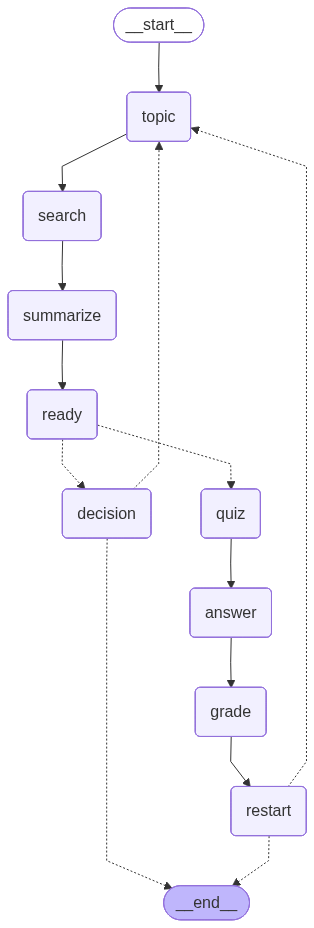

In [35]:
# Run the application
app = graph.compile()

app

In [36]:
app.invoke({})


 -------------------------------------------- Content retrieved --------------------------------------------

Tuberculosis, often referred to as TB, is a bacterial infection caused by *Mycobacterium tuberculosis*. It primarily affects the lungs but can also impact other parts of the body. TB is a serious illness that can be life-threatening if left untreated. 

The symptoms of tuberculosis include a persistent cough, often with phlegm, and other respiratory issues. It is important to note that some people with TB may not show any symptoms, which is known as latent or inactive TB. This means they carry the bacteria but do not experience any illness. 

Diagnosis of TB involves skin or blood tests. If you have been exposed to TB or are experiencing symptoms, it is crucial to seek medical advice immediately. Healthcare providers can determine if you have latent TB or active TB disease. 

Active TB disease occurs when the bacteria multiply and cause symptoms. It is contagious and can be sp

{'topic': 'bleeding after operation',
 'search': "{'query': 'Please provide medical explanation about symptoms and treatments for bleeding after operation', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://surgeonschoice.com/content/download/1545/12376/version/1/file/66326+-+Post+Op+Bleeding+Care+Notes+-+PROOF.PDF', 'title': '[PDF] POST OPERATIVE BLEEDING: Care Notes', 'content': '“What increases my risk of post-operative bleeding?” • Vitamin or herbal supplements that affect blood clotting, such as vitamin E, ginkgo, ginseng, turmeric, ginger or feverfew. • Medicines such as aspirin that thin your blood and prevent blood clots. “What should I do if I take medication such as Aspirin, Xarelto, Warfarin or Clopidogrel, which are blood thinners?” You are at a slightly higher risk of bleeding but do not stop taking your medication unless advised to do so by your doctor. “What is the treatment for prolonged post- operative bleeding?” A blood transfusio